In [1]:
import pickle
import os, sys
from pathlib import Path
import pandas as pd

cur_dir = os.getcwd()
path = Path(cur_dir)
sys.path.insert(0, str(path.parent.absolute()))

from src.preprocess import preprocess_df
from src.network_model import NetworkModel
from src.analyze_cic_ids import *

import networkx as nx
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
import scipy
from PIL import Image
import pickle
import seaborn as sns

from test_network_model_graph import generate_random_mvn_model, samples2flows
from test_flow_based_classification import generate_n_flow_modes
from test_nre_classification import generate_n_state_flows

In [26]:
import importlib
import src.analyze_cic_ids

importlib.reload(src.analyze_cic_ids)
from src.analyze_cic_ids import *

# Flow-Based Classification

In [2]:
import importlib
import test_flow_based_classification

importlib.reload(test_flow_based_classification)
from test_flow_based_classification import *

Text(0.5, 1.0, 'Flow Features of Modes')

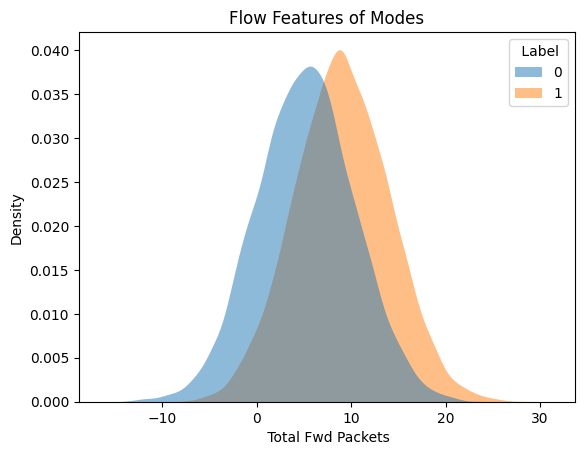

In [3]:
df_test, _ = generate_n_flow_modes(2)
sns.kdeplot(data=df_test, x=' Total Fwd Packets', hue=' Label', fill=True, alpha=0.5, linewidth=0)
plt.title('Flow Features of Modes')

In [4]:
df_test[' Label'].describe()

count     100000
unique         2
top            0
freq       85227
Name:  Label, dtype: object

In [5]:
df_test.describe()

,Timestamp
count,100000
mean,2023-06-06 02:50:13.559999744
min,2023-06-06 00:00:00
25%,2023-06-06 01:25:21
50%,2023-06-06 02:50:28
75%,2023-06-06 04:15:06
max,2023-06-06 05:40:08


Text(0.5, 1.0, 'Flow Features of Modes')

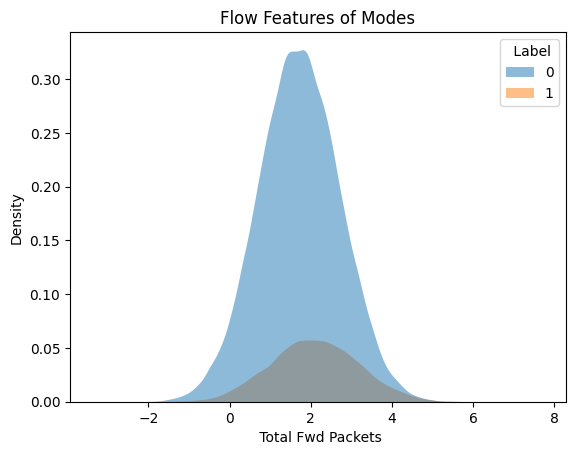

In [4]:
df_test, flow_means = simulate_attack(p_attack=0.1, n_flow=1000)
sns.kdeplot(data=df_test, x=' Total Fwd Packets', hue=' Label', fill=True, alpha=0.5, linewidth=0)
plt.title('Flow Features of Modes')

,Accuracy,Precision,Recall,Balanced Accuracy,f1
Linear Support Vector Machines,0.995522,0.995522,1.0,0.5,0.997756
Decision Tree,0.995522,0.995522,1.0,0.5,0.997756
Random Forest,0.995522,0.995522,1.0,0.5,0.997756
Naive Bayes,0.995522,0.995522,1.0,0.5,0.997756


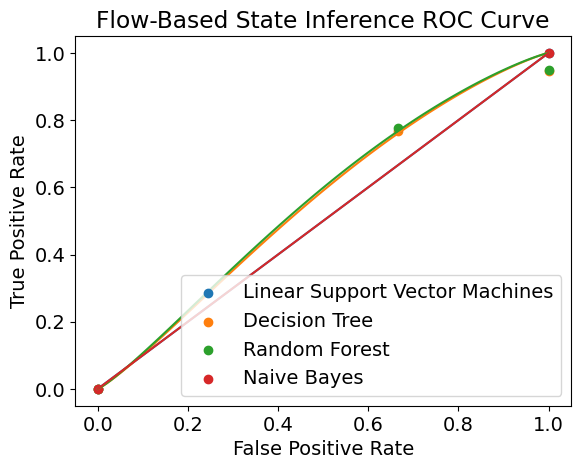

In [5]:
models = {'Linear Support Vector Machines': LinearSVC(dual='auto'), 'Decision Tree': DecisionTreeClassifier(),
              'Random Forest': RandomForestClassifier(), 'Naive Bayes': GaussianNB()}

roc_curves = {}
df_test_model = flow_based_classification(df_test, models, benign_label='0', t_graph=10, roc_curves=roc_curves)
fig = plot_roc_curves(roc_curves, title='Flow-Based State Inference ROC Curve')
df_test_model

In [3]:
with open('internal_nodes_tuesday.pickle', 'rb') as handle:
    samp_names = pickle.load(handle) 
len(samp_names)

21

# Network Risk Estimation

In [6]:
import importlib
import test_nre_classification

importlib.reload(test_nre_classification)
from test_nre_classification import *

In [7]:
 df_test, f_list = generate_n_state_flows(2, max_flow_sep=0.4, min_flow_per_sample=5,
                                             max_flow_per_sample=10, date_col='t', label_col='y')
print(df_test)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:30<00:00, 165.68it/s]


                            t  Source IP  Destination IP  Total Fwd Packets   
0     2023-06-06 00:00:00.259          4               3           0.360681  \
1     2023-06-06 00:00:00.471          2               4           0.117564   
2     2023-06-06 00:00:00.821          0               1          -0.688155   
3     2023-06-06 00:00:01.152          3               0           0.363959   
4     2023-06-06 00:00:01.420          0               3            0.33932   
...                       ...        ...             ...                ...   
85274 2023-06-06 07:05:35.232          0               3           0.099427   
85275 2023-06-06 07:05:35.441          0               2          -0.246519   
85276 2023-06-06 07:05:35.734          4               0           0.229641   
85277 2023-06-06 07:05:35.992          3               0          -0.678636   
85278 2023-06-06 07:05:36.201          3               1           0.493408   

       Total Backward Packets  y  
0               

In [3]:
df_test, f_list = simulate_changing_network(min_flow_per_sample=5, max_flow_per_sample=10, date_col='t',
                                                label_col='y')
df_test

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:05<00:00, 176.79it/s]


,t,Source IP,Destination IP,Total Fwd Packets,Total Backward Packets,y
0,2023-06-06 00:00:00.258,0,3,-1.784014,0.807369,1
1,2023-06-06 00:00:00.548,2,0,1.103249,-1.784014,1
2,2023-06-06 00:00:00.869,4,0,-0.206927,-1.784014,1
3,2023-06-06 00:00:01.253,3,0,0.807369,-1.784014,1
4,2023-06-06 00:00:01.580,2,0,1.103249,-1.784014,1
...,...,...,...,...,...,...
84844,2023-06-06 07:03:51.309,2,3,1.727707,0.317593,0
84845,2023-06-06 07:03:51.598,0,1,0.393894,0.888522,0
84846,2023-06-06 07:03:51.913,3,1,0.317593,0.888522,0
84847,2023-06-06 07:03:52.303,4,2,2.368473,1.727707,0


In [5]:
f_list

[(array([[1.        , 0.58668192, 0.76405929, 0.21264636, 0.74887306],
         [0.58668192, 1.        , 0.67034747, 0.0367789 , 0.3593748 ],
         [0.76405929, 0.67034747, 1.        , 0.14453883, 0.51115776],
         [0.21264636, 0.0367789 , 0.14453883, 1.        , 0.79167972],
         [0.74887306, 0.3593748 , 0.51115776, 0.79167972, 1.        ]]),
  array([[4.71467411, 0.        , 0.        , 0.        , 0.        ],
         [0.        , 1.01652587, 0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.25161565, 0.        , 0.        ],
         [0.        , 0.        , 0.        , 0.39058866, 0.        ],
         [0.        , 0.        , 0.        , 0.        , 0.44361364]])),
 (array([[1.        , 0.91128111, 0.69880955, 0.76799639, 0.59870061],
         [0.91128111, 1.        , 0.78374592, 0.91667315, 0.76932361],
         [0.69880955, 0.78374592, 1.        , 0.61459906, 0.80250704],
         [0.76799639, 0.91667315, 0.61459906, 1.        , 0.84512752],
 

1
Current time and samples shape:  2023-06-06 00:16:40.389000 (50, 5)
2
Current time and samples shape:  2023-06-06 00:33:20.671000 (50, 5)
3
Current time and samples shape:  2023-06-06 00:50:00.756000 (50, 5)
4
Current time and samples shape:  2023-06-06 01:06:41.040000 (50, 5)
5
Current time and samples shape:  2023-06-06 01:23:21.281000 (50, 5)
6
Current time and samples shape:  2023-06-06 01:40:01.505000 (50, 5)
7
Current time and samples shape:  2023-06-06 01:56:41.551000 (50, 5)
8
Current time and samples shape:  2023-06-06 02:13:21.698000 (50, 5)
9
Current time and samples shape:  2023-06-06 02:30:01.882000 (50, 5)
10
Current time and samples shape:  2023-06-06 02:46:42.140000 (50, 5)
11
Current time and samples shape:  2023-06-06 03:03:22.446000 (50, 5)
12
Current time and samples shape:  2023-06-06 03:20:02.479000 (50, 5)
13
Current time and samples shape:  2023-06-06 03:36:42.748000 (50, 5)
14
Current time and samples shape:  2023-06-06 03:53:22.770000 (50, 5)
15
Current time

C:\Users\bayer\PycharmProjects\NRE\venv2\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


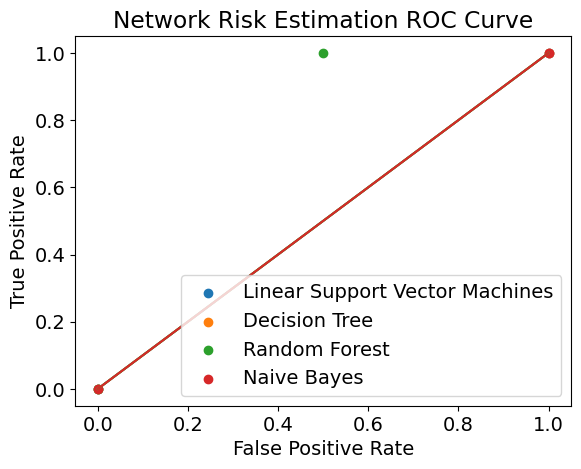

In [8]:
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

models = {'Linear Support Vector Machines': LinearSVC(dual='auto'), 'Decision Tree': DecisionTreeClassifier(),
              'Random Forest': RandomForestClassifier(), 'Naive Bayes': GaussianNB()}

roc_curves = {}
df_test_model = nre_classification(df_test, models, date_col='t', label_col='y', benign_label='0',
                                   t_graph=1000, time_scale='sec', standardize=False, sync_window_size=20,
                                   conn_param=None, roc_curves=roc_curves)
fig = plot_roc_curves(roc_curves, title='Network Risk Estimation ROC Curve')

print(df_test_model)
plt.show()